# 📊 Regresión Logística Binaria
Construcción, entrenamiento y evaluación de un modelo de **Regresión Logística Binaria**
para predecir si una película será considerada **exitosa** según su calificación IMDb.

| | |
|---|---|
| **Variable objetivo (Y)** | `es_exitosa` (1 = IMDb ≥ 7, 0 = IMDb < 7) |
| **Variables predictoras (X)** | `anio`, `genero`, `director`, `actores` |
| **Modelo** | `LogisticRegression` (scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 70/30 · 60/40 |

> Pipeline ETL OMDb API — datos almacenados en PostgreSQL.

In [16]:
# ─────────────────────────────────────────────────────────────
# CELDA 0 — Conexión a ETL-Proyecto y configuración
# ─────────────────────────────────────────────────────────────

import sys
import os

# Detectar raíz del proyecto
if "notebooks" in os.getcwd():
    ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
else:
    ROOT_DIR = os.getcwd()

ETL_DIR = os.path.join(ROOT_DIR, "Etl-Proyecto")

if ETL_DIR not in sys.path:
    sys.path.append(ETL_DIR)

# Carpeta para gráficas
GRAFICAS_DIR = os.path.join(
    ROOT_DIR,
    "data",
    "graficas",
    "regresion_logistica_binaria"
)

os.makedirs(GRAFICAS_DIR, exist_ok=True)

print("=" * 60)
print("CONFIGURACIÓN DEL PROYECTO")
print("=" * 60)
print(f"📁 ROOT_DIR      : {ROOT_DIR}")
print(f"📁 ETL_DIR       : {ETL_DIR}")
print(f"📁 GRAFICAS_DIR  : {GRAFICAS_DIR}")
print("✅ Configuración completada")

CONFIGURACIÓN DEL PROYECTO
📁 ROOT_DIR      : /home/desarrollo/Grupo6_Obregon_Heredia_MD1
📁 ETL_DIR       : /home/desarrollo/Grupo6_Obregon_Heredia_MD1/Etl-Proyecto
📁 GRAFICAS_DIR  : /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/regresion_logistica_binaria
✅ Configuración completada


# 📚 I. Configuración Inicial — Importaciones y Estilo Visual
## I. Configuración Inicial — Importaciones y Estilo Visual

Importamos las librerías necesarias para:

- manipulación de datos
- visualización
- entrenamiento del modelo
- evaluación de métricas
- conexión con PostgreSQL

In [17]:
# ── CELDA 1: Importaciones ────────────────────────────────────────

import sys
import os

ROOT_DIR = os.path.abspath("..")
sys.path.insert(0, ROOT_DIR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# Variables de entorno
load_dotenv(os.path.join(ROOT_DIR, "Etl-Proyecto", ".env"))

DATABASE_URL = os.getenv("DATABASE_URL")

engine = create_engine(DATABASE_URL)

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11
})

print("✅ Librerías importadas correctamente")
print(f"📦 pandas  {pd.__version__}")
print(f"📦 numpy   {np.__version__}")
print(f"📦 seaborn {sns.__version__}")

✅ Librerías importadas correctamente
📦 pandas  2.3.3
📦 numpy   1.26.4
📦 seaborn 0.13.2


## II. Extracción de Datos desde PostgreSQL

La consulta SQL obtiene información de películas desde PostgreSQL y
crea la variable objetivo binaria `es_exitosa`.

### Regla aplicada

- `1` → película con IMDb ≥ 7
- `0` → película con IMDb < 7

In [18]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────

SQL_QUERY = """
SELECT
    anio,
    genero,
    director,
    actores,
    imdb_rating,

    CASE
        WHEN imdb_rating >= 7 THEN 1
        ELSE 0
    END AS es_exitosa

FROM registro_peliculas
WHERE imdb_rating IS NOT NULL
"""

with engine.connect() as conn:
    df_movies = pd.read_sql(text(SQL_QUERY), conn)

print("✅ Datos cargados correctamente")
print(f"📊 Filas: {df_movies.shape[0]:,}")
print(f"📊 Columnas: {df_movies.shape[1]}")

print("\n📋 Primeras filas:")
display(df_movies.head())

✅ Datos cargados correctamente
📊 Filas: 528
📊 Columnas: 6

📋 Primeras filas:


,anio,genero,director,actores,imdb_rating,es_exitosa
0,2010,"Action, Adventure, Sci-Fi",Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",8.8,1
1,2014,"Adventure, Drama, Sci-Fi",Christopher Nolan,"Matthew McConaughey, Anne Hathaway, Jessica Ch...",8.7,1
2,2008,"Action, Crime, Drama",Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart",9.1,1
3,2019,"Drama, Thriller",Bong Joon Ho,"Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong",8.5,1
4,2009,"Action, Adventure, Fantasy",James Cameron,"Sam Worthington, Zoe Saldaña, Sigourney Weaver",7.9,1


## III. Validación y Exploración del Dataset

Se valida:

- tipos de datos
- valores nulos
- balance de clases
- distribución inicial

In [19]:
# ── CELDA 3: Validación del dataset ───────────────────────────────

print("=" * 60)
print("VALIDACIÓN DEL DATASET")
print("=" * 60)

print("\n📋 Tipos de datos:")
display(df_movies.dtypes)

print("\n📋 Valores nulos:")
display(df_movies.isnull().sum())

balance = df_movies['es_exitosa'].value_counts()

print("\n🎯 Balance de clases:")
print(balance)

print("\n📊 Distribución porcentual:")
print(df_movies['es_exitosa'].value_counts(normalize=True) * 100)

VALIDACIÓN DEL DATASET

📋 Tipos de datos:


anio             int64
genero          object
director        object
actores         object
imdb_rating    float64
es_exitosa       int64
dtype: object


📋 Valores nulos:


anio           0
genero         0
director       0
actores        0
imdb_rating    0
es_exitosa     0
dtype: int64


🎯 Balance de clases:
es_exitosa
1    367
0    161
Name: count, dtype: int64

📊 Distribución porcentual:
es_exitosa
1    69.507576
0    30.492424
Name: proportion, dtype: float64


## IV. Preprocesamiento de Datos

### Pasos aplicados

1. Eliminación de nulos
2. Codificación de variables categóricas
3. Escalado de variables numéricas
4. Construcción de X e y

In [20]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────

df = df_movies.copy()

# Eliminar imdb_rating para evitar fuga accidental
df.drop(columns=['imdb_rating'], inplace=True)

# Eliminar nulos
df.dropna(inplace=True)

# Cantidad de actores
df['cantidad_actores'] = df['actores'].apply(
    lambda x: len(str(x).split(','))
)
df.drop(columns=['actores'], inplace=True)

# ── Agrupar directores poco frecuentes → 'Otro' ──────────────
TOP_N_DIRECTORES = 20
top_directores = df['director'].value_counts().head(TOP_N_DIRECTORES).index
df['director'] = df['director'].apply(
    lambda x: x if x in top_directores else 'Otro'
)

# ── Género: quedarse solo con el primero (antes de la coma) ───
df['genero'] = df['genero'].str.split(',').str[0].str.strip()

# ── Dummies solo sobre categorías reducidas ───────────────────
df = pd.get_dummies(df, columns=['genero', 'director'], drop_first=True)

# Variable objetivo y features
y = df['es_exitosa']
X = df.drop(columns=['es_exitosa'])

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Preprocesamiento completado")
print(f"📊 Shape X : {X_scaled.shape}")
print(f"📊 Shape y : {y.shape}")
print(f"\n📌 Columnas generadas:")
print(list(X.columns))
print(f"\n📌 Balance de clases:")
print(y.value_counts())

✅ Preprocesamiento completado
📊 Shape X : (528, 34)
📊 Shape y : (528,)

📌 Columnas generadas:
['anio', 'cantidad_actores', 'genero_Adventure', 'genero_Animation', 'genero_Biography', 'genero_Comedy', 'genero_Crime', 'genero_Documentary', 'genero_Drama', 'genero_Fantasy', 'genero_Horror', 'genero_Mystery', 'genero_Short', 'genero_Thriller', 'director_Alfred Hitchcock', 'director_Bennett Miller', 'director_Christopher Nolan', 'director_Damien Chazelle', 'director_Darren Aronofsky', 'director_David Fincher', 'director_Ethan Coen, Joel Coen', 'director_Francis Ford Coppola', 'director_Frank Darabont', 'director_James Cameron', 'director_Martin Scorsese', 'director_N/A', 'director_Otro', 'director_Peter Jackson', 'director_Quentin Tarantino', 'director_Ridley Scott', 'director_Robert Zemeckis', 'director_Ron Howard', 'director_Stanley Kubrick', 'director_Steven Spielberg']

📌 Balance de clases:
es_exitosa
1    367
0    161
Name: count, dtype: int64


In [21]:
# ── CELDA 4b: Función con mejor modelo de GridSearch ─────────────

def entrenar_evaluar(X, y, test_size, nombre):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Usar los mejores hiperparámetros encontrados por GridSearchCV
    modelo = LogisticRegression(
        **grid_search.best_params_,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'   : nombre,
        'modelo'   : modelo,
        'y_test'   : y_test,
        'y_pred'   : y_pred,
        'fpr'      : fpr,
        'tpr'      : tpr,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_prob)
    }

print("✅ Función lista con hiperparámetros optimizados")

✅ Función lista con hiperparámetros optimizados


In [22]:
# ── CELDA 4c: Oversample con resample ────────────────────────────
from sklearn.utils import resample

# Separar clases
df_majority = pd.DataFrame(X_scaled[y == 1], columns=X.columns)
df_minority = pd.DataFrame(X_scaled[y == 0], columns=X.columns)

print(f"Clase mayoritaria (1): {len(df_majority)}")
print(f"Clase minoritaria (0): {len(df_minority)}")

# Oversample de la clase minoritaria
df_minority_upsampled = resample(
    df_minority,
    replace=True,                    # muestrea con reemplazo
    n_samples=len(df_majority),      # iguala a la clase mayoritaria
    random_state=42
)

# Reconstruir dataset balanceado
X_balanced = pd.concat([df_majority, df_minority_upsampled]).values
y_balanced = np.array(
    [1] * len(df_majority) + [0] * len(df_minority_upsampled)
)

print(f"\n✅ Oversample completado")
print(f"   Clase 1 : {sum(y_balanced == 1)}")
print(f"   Clase 0 : {sum(y_balanced == 0)}")
print(f"   Total   : {len(y_balanced)}")

Clase mayoritaria (1): 367
Clase minoritaria (0): 161

✅ Oversample completado
   Clase 1 : 367
   Clase 0 : 367
   Total   : 734


In [23]:
# ── CELDA 4d: GridSearchCV para hiperparametrización ─────────────
from sklearn.model_selection import GridSearchCV

# Grilla de hiperparámetros a probar
param_grid = {
    'C':           [0.01, 0.1, 1, 10, 100],
    'penalty':     ['l1', 'l2'],
    'solver':      ['liblinear'],
    'max_iter':    [1000]
}

modelo_base = LogisticRegression(random_state=42)

grid_search = GridSearchCV(
    estimator  = modelo_base,
    param_grid = param_grid,
    cv         = 5,              # validación cruzada 5 folds
    scoring    = 'f1',           # optimizar por F1
    n_jobs     = -1,             # usar todos los núcleos
    verbose    = 1
)

grid_search.fit(X_balanced, y_balanced)

print("✅ GridSearchCV completado")
print(f"\n📌 Mejores hiperparámetros:")
print(f"   C       : {grid_search.best_params_['C']}")
print(f"   penalty : {grid_search.best_params_['penalty']}")
print(f"\n📌 Mejor F1 en validación cruzada: {grid_search.best_score_:.4f}")

mejor_modelo = grid_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/desarrollo/Grupo6_Obregon_Heredia_MD1/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/desarrollo/Grupo6_Obregon_Heredia_MD1/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/desarrollo/Grupo6_Obregon_Heredia_MD1/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 inst

✅ GridSearchCV completado

📌 Mejores hiperparámetros:
   C       : 10
   penalty : l2

📌 Mejor F1 en validación cruzada: 0.7612


/home/desarrollo/Grupo6_Obregon_Heredia_MD1/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## V. Entrenamiento y Evaluación

Se entrenará el modelo usando tres particiones:

- 80/20
- 70/30
- 60/40

Se evaluarán las métricas:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

## V. Entrenamiento y Evaluación

Se entrenará el modelo usando tres particiones:

- 80/20
- 70/30
- 60/40

Se evaluarán las métricas:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [24]:
# ── CELDA 5: Función entrenar_evaluar ────────────────────────────

def entrenar_evaluar(X, y, test_size, nombre):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre': nombre,
        'modelo': modelo,
        'y_test': y_test,
        'y_pred': y_pred,
        'fpr': fpr,
        'tpr': tpr,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

print("✅ Función entrenar_evaluar creada correctamente\n")

# ─ Ejecutar splits ─────────────────────────────────────

resultados = [
    entrenar_evaluar(X_balanced, y_balanced, 0.20, "Split 80/20"),
    entrenar_evaluar(X_balanced, y_balanced, 0.30, "Split 70/30"),
    entrenar_evaluar(X_balanced, y_balanced, 0.40, "Split 60/40")
]

print("✅ Modelos entrenados correctamente")

for r in resultados:
    print(f"\n📊 {r['nombre']}")
    print(f"Accuracy : {r['accuracy']:.4f}")
    print(f"Precision: {r['precision']:.4f}")
    print(f"Recall   : {r['recall']:.4f}")
    print(f"F1-Score : {r['f1']:.4f}")
    print(f"ROC-AUC  : {r['roc_auc']:.4f}")

✅ Función entrenar_evaluar creada correctamente

✅ Modelos entrenados correctamente

📊 Split 80/20
Accuracy : 0.8231
Precision: 0.8133
Recall   : 0.8356
F1-Score : 0.8243
ROC-AUC  : 0.8888

📊 Split 70/30
Accuracy : 0.7919
Precision: 0.8077
Recall   : 0.7636
F1-Score : 0.7850
ROC-AUC  : 0.8007

📊 Split 60/40
Accuracy : 0.8027
Precision: 0.8069
Recall   : 0.7959
F1-Score : 0.8014
ROC-AUC  : 0.8278



## VI. Curvas ROC

La curva ROC permite evaluar la capacidad de discriminación
del modelo para clasificar películas exitosas.

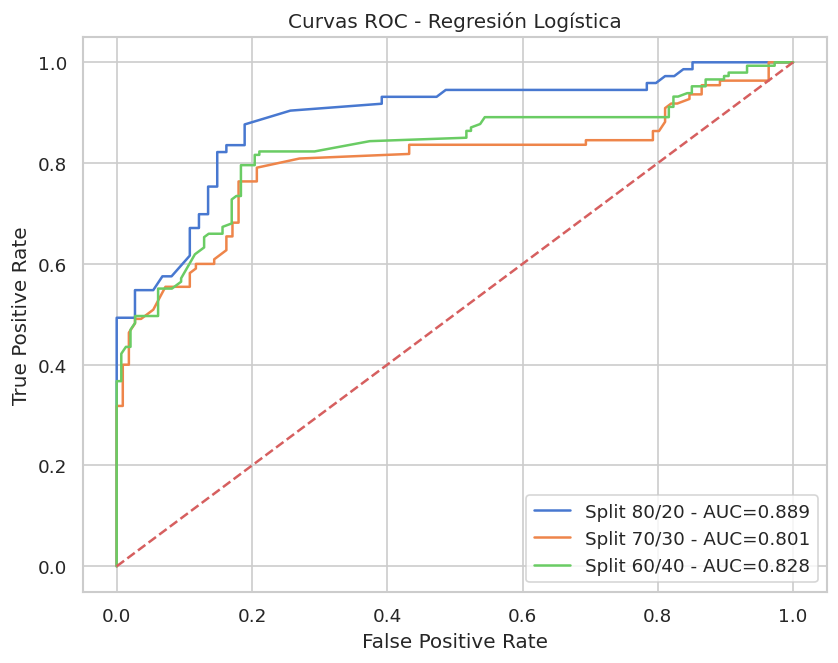

✅ Curvas ROC generadas correctamente
💾 Guardado en: /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/regresion_logistica_binaria/roc_logistica.png


In [25]:
# ── CELDA 6: Curvas ROC ──────────────────────────────────────────

plt.figure(figsize=(8,6))

for r in resultados:

    plt.plot(
        r['fpr'],
        r['tpr'],
        label=f"{r['nombre']} - AUC={r['roc_auc']:.3f}"
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curvas ROC - Regresión Logística")

plt.legend()

ruta = os.path.join(GRAFICAS_DIR, "roc_logistica.png")

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print("✅ Curvas ROC generadas correctamente")
print(f"💾 Guardado en: {ruta}")

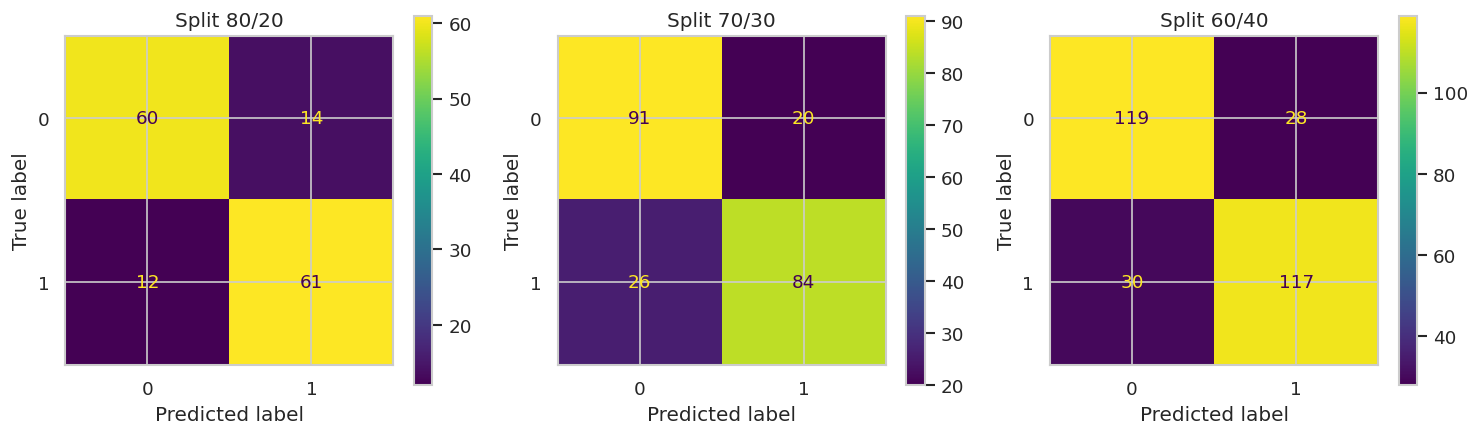

✅ Matrices de confusión generadas


In [26]:
# ── CELDA 7: Matrices de confusión ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, r in zip(axes, resultados):

    cm = confusion_matrix(r['y_test'], r['y_pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(ax=ax)

    ax.set_title(r['nombre'])

ruta = os.path.join(GRAFICAS_DIR, "confusion_matrix.png")

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print("✅ Matrices de confusión generadas")

In [27]:
# ── CELDA 8: Comparativa de métricas ─────────────────────────────

metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

df_metricas = pd.DataFrame([
    {
        'Split': r['nombre'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1'],
        'ROC_AUC': r['roc_auc']
    }
    for r in resultados
])

display(df_metricas)

print("✅ Tabla comparativa creada correctamente")

,Split,Accuracy,Precision,Recall,F1,ROC_AUC
0,Split 80/20,0.823129,0.813333,0.835616,0.824324,0.888837
1,Split 70/30,0.791855,0.807692,0.763636,0.785047,0.800655
2,Split 60/40,0.802721,0.806897,0.795918,0.801370,0.827803


✅ Tabla comparativa creada correctamente


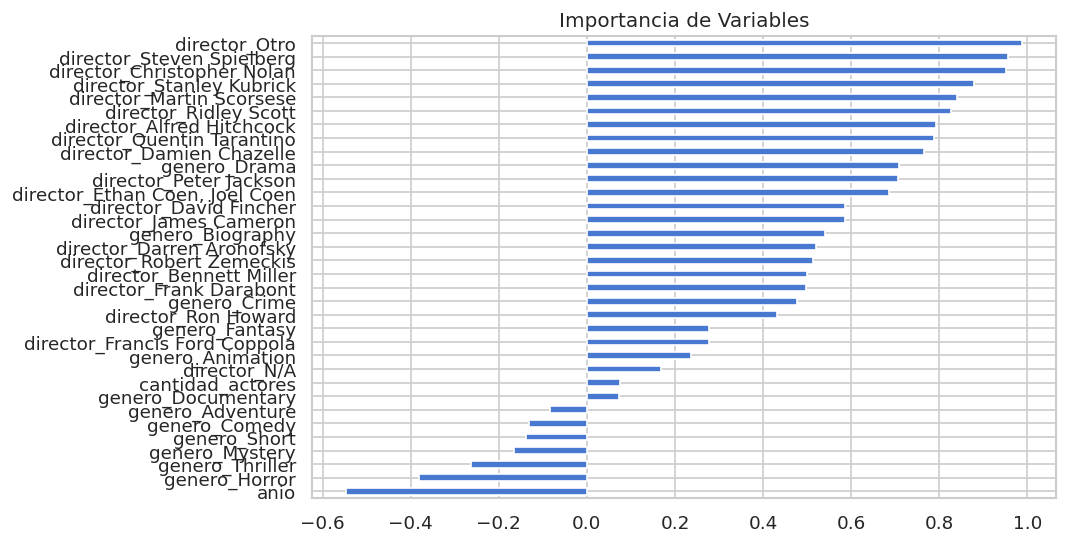

✅ Coeficientes visualizados correctamente


In [28]:
# ── CELDA 9: Importancia de coeficientes ───────────────────────

modelo = resultados[0]['modelo']

coeficientes = pd.Series(
    modelo.coef_[0],
    index=X.columns
)

coeficientes.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Importancia de Variables")

ruta = os.path.join(GRAFICAS_DIR, "coeficientes.png")

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print("✅ Coeficientes visualizados correctamente")